# Model calibration: Effects of to BdJEL423 *Discoglossus pictus* juveniles

This section documents the inference of Bd growth and effect parameters to describe the distribution of observed Bd loads and effects of *D. pictus* juvenile growth.

## Setup

In [7]:
using DrWatson
@quickactivate "."
#using Pkg; Pkg.instantiate()

In [8]:
const SAVETAG_LARVALFIT = "input/Discoglossus_larvae" # directory from which larval/metamorph parameters are loaded
const SAVETAG_JUVENILEFIT = "input/Discoglossus_juveniles" # directory from which juvenile/adult parameters are loaded
const SAVETAG_CORRECTION_FACTORS = "Discoglossus_24D_exp2_control"
const SAVETAG = "Discoglossus_BdJEL423_exp2"

using Revise
includet(scriptsdir("ModelFitting_Discoglossus_BdJEL423_exp2.jl"));

In [9]:
using Pkg
Pkg.status("AmphiDEB") # show version of AmphiDEB used

Status `C:\Users\shansul\Documents\AmphiDEBResearch-1\WP02_TKTD\Project.toml`
  [eee04faf] AmphiDEB v0.3.8 `https://github.com/simonhansul/amphideb.git#main`


In [10]:
Pkg.status("EcotoxSystems") # show version of EcotoxSystems used

Status `C:\Users\shansul\Documents\AmphiDEBResearch-1\WP02_TKTD\Project.toml`
  [a070e96f] EcotoxSystems v0.2.3 `https://github.com/simonhansul/ecotoxsystems.jl.git#main`


## Technical notes 

The priors for Bd growth parameters were set manually. <br> 
Using specific priors for the most influential Bd growth/infection parameters is extremely helpful for this calibration problem, 
due to the correlation between Bd growth and effect parameters. <br>
The plotting functions are set up to display the distributions of juvenile wet mass over individuals, but the model is fitted to averages. 

## Simulation setup

In [11]:
f = setup_modelfit_exp2_Bd("M");

┌ Warning: Using arrays or dicts to store parameters of different types can hurt performance.
│ Consider using tuples instead.
└ @ SciMLBase C:\Users\shansul\.julia\packages\SciMLBase\wfZCo\src\performance_warnings.jl:33
┌ Info: 
│         Estimating 6 parameters: 
│         ["pth.gamma", "pth.eta", "pth.sigma1", "spc.Chi", "spc.E_P[2]", "spc.B_P[2]"]
│         
└ @ EcotoxModelFitting C:\Users\shansul\.julia\packages\EcotoxModelFitting\aC0gq\src\modelfit.jl:77
┌ Info: Normalizing data weights
└ @ EcotoxModelFitting C:\Users\shansul\.julia\packages\EcotoxModelFitting\aC0gq\src\modelfit.jl:145
┌ Info: No column `observation_weight` found in data key juveniles_raw. Assuming uniform weights.
└ @ EcotoxModelFitting C:\Users\shansul\.julia\packages\EcotoxModelFitting\aC0gq\src\modelfit.jl:98
┌ Info: No column `observation_weight` found in data key juveniles_aggregated. Assuming uniform weights.
└ @ EcotoxModelFitting C:\Users\shansul\.julia\packages\EcotoxModelFitting\aC0gq\src\modelfit.jl:9

## Prior check

With the model fit set up, we can perform a prior predictive check and compare the range of prior predictions with the observations.

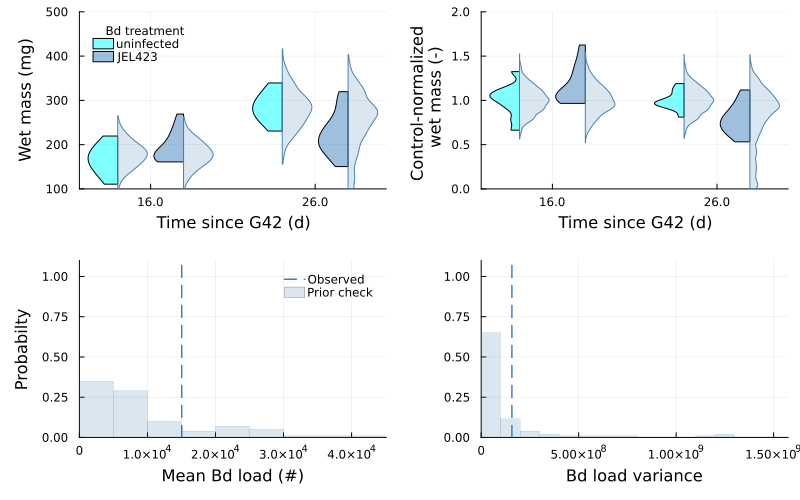

In [7]:
@suppress global prior_check = prior_predictive_check(f; compute_loss = true, n = 100);

plt = f.plot_data()
plot_sims_exp2_Bd!(plt, prior_check.predictions; label = "Prior check")
plt

From the prior predictive check, we can retrieve a preliminary parameter estimate.

In [ ]:
p_opt = prior_check.samples[argmin(prior_check.losses)]

6-element Vector{Float64}:
  0.17380748284170028
 97.48947461353733
  1.1962927254134437
  0.8868196796992134
 23.372506538645382
  2.2028936219186015

The description of the data by this preliminary estimate is already somewhat reasonable.

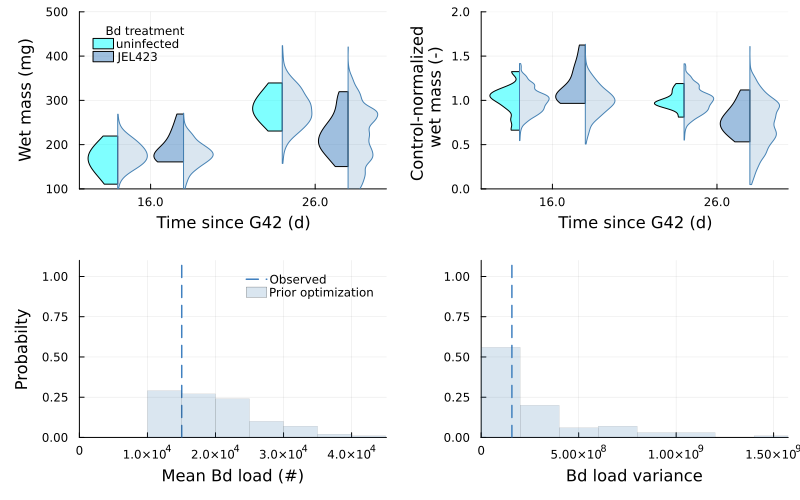

In [13]:
sim_opt = [f.simulator(p_opt) for _ in 1:100];
plt = f.plot_data()
plot_sims_exp2_Bd!(plt, sim_opt; label = "Prior optimization")
plt

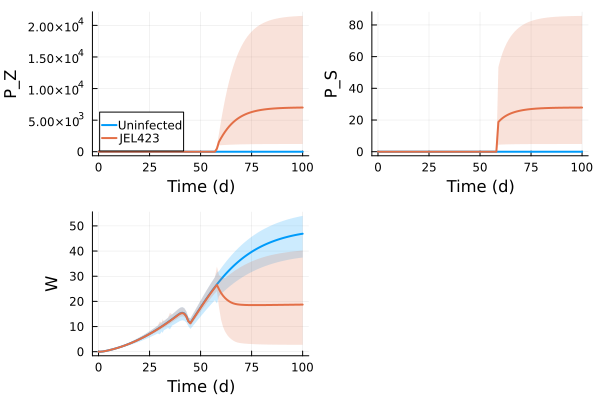

In [15]:
sim_opt = f.simulator(p_opt, return_raw = true)

@df sim_opt plot(
    groupedlineplot(ylabel = "P_Z", :t, :P_Z, :treatment_id), 
    groupedlineplot(ylabel = "P_S", :t, :P_S, :treatment_id), 
    groupedlineplot(ylabel = "W", :t, :S .+ :E_mt, :treatment_id), 
    xlabel = "Time (d)", leg = [:bottomleft false false], label = ["Uninfected" "JEL423"], 
    lw = 2, fillalpha = 0.2
)

## Parameter inference

In [11]:
lowsettings = (
    :n => 10,
    :q_dist => 0.1, 
    :t_max => 1,
    :evals_per_sample => 1
)

highsettings = (
    :n => 10_000, 
    :q_dist => 0.1, 
    :t_max => 5,
    :evals_per_sample => 1
)

singlepop = (
    :n => 100_000,
    :q_dist => 0.01, 
    :t_max => 0,
    :evals_per_sample => 1
)

savedir = datadir("sims")
savetag = SAVETAG
continue_from = nothing

pmchist = run_PMC!(
    f; 
    singlepop...,
    savedir = savedir,
    savetag = savetag, 
    paramlabels = paramlabels, 
    continue_from = continue_from
)

┌ Info: Saving results to c:\Users\simon\Documents\AmphiDEBResearch\WP02_TKTD\data\sims\Discoglossus_BdJEL423_exp2
└ @ EcotoxModelFitting C:\Users\simon\.julia\packages\EcotoxModelFitting\aC0gq\src\populationmontecarlo.jl:119
┌ Info: #### ---- Evaluating 100000 initial samples on 24 threads ---- ####
└ @ EcotoxModelFitting C:\Users\simon\.julia\packages\EcotoxModelFitting\aC0gq\src\populationmontecarlo.jl:132
Progress:  22%|██████████                               |  ETA: 1:32:20KExcessive output truncated after 524480 bytes.

(particles = [[0.10536874465249597 0.10087021152408036 … 0.07355649795998179 0.05652295134577531; 135.92702859166243 60.77347542429079 … 198.98672886699774 195.909065274412; … ; 18542.79070829555 10947.233144250175 … 10639.085457126053 18411.291534373944; 3.0176181079103994 2.0631553493556867 … 3.7686711797631207 2.443650935396395]], weights = [[0.0019919971739033064, 0.0012397483804169579, 0.0007953317933486316, 0.0022592932250078746, 0.001922398448072361, 0.00020237474440235002, 0.0018779872190311676, 0.002482441744563387, 0.000825431270420677, 0.0004817260569110291  …  0.0004040897568178156, 0.0005503378772476582, 0.0008887609062637693, 0.0017595958106530279, 0.0015849365218076627, 3.595339013877827e-5, 0.0007243347211780705, 0.0008734664688268818, 0.0006457826793713772, 0.001764498289728432]], dists = [[0.030000783385063574 0.04064305738123374 … 0.04738647723678045 0.033576979037893154]], vars = [[0.012943390706821522, 4039.0451833160996, 5.3310426994164855e-6, 0.19117926637362195,

### Posterior check: Retrodicted Bd loads and effects on growth

┌ Info: #### ---- Best fit ---- ####
└ @ Main c:\Users\shansul\Documents\AmphiDEBResearch-1\WP02_TKTD\notebooks\jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_X33sZmlsZQ==.jl:2


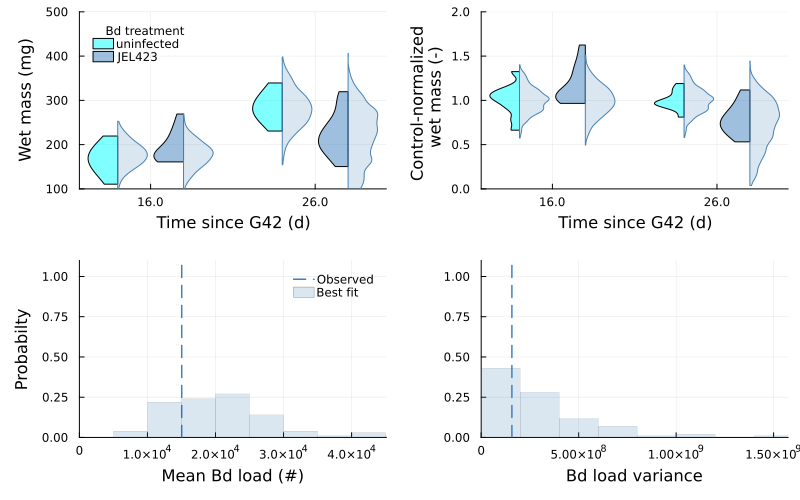

"c:\\Users\\shansul\\Documents\\AmphiDEBResearch-1\\WP02_TKTD\\data\\sims\\Discoglossus_BdJEL423_exp2\\VPC_posterior_bestfit.png"

In [22]:
savetag = SAVETAG
@info "#### ---- Best fit ---- ####"

let plt = f.plot_data()

    p_opt = f.accepted[:,argmin(vec(f.losses))]
    sim_opt = [f.simulator(p_opt) for _ in 1:100]

    plot_sims_exp2_Bd!(plt, sim_opt, label = "Best fit")
    display(plt)
    
    if !isnothing(savetag)
        savefig(plot(plt, dpi = 400), datadir("sims", "$(savetag)", "VPC_posterior_bestfit.png"))
    end
end

### Posterior distributions

Clearly, the slope $\beta_{Bd,M}$ cannot inferred from this data. There is also some uncertainty around the remaining parameters. 
The data was apparently most informative regarding the density-dependent killing rate $\sigma_{1,Bd}$, which is important for the equilibrium conditions of Bd loads. <br>
For the killing rate modifier $\chi_{Bd}$ and median effective Bd load $e_{Bd,M}$, the posterior distributions were also considerably narrowed down.

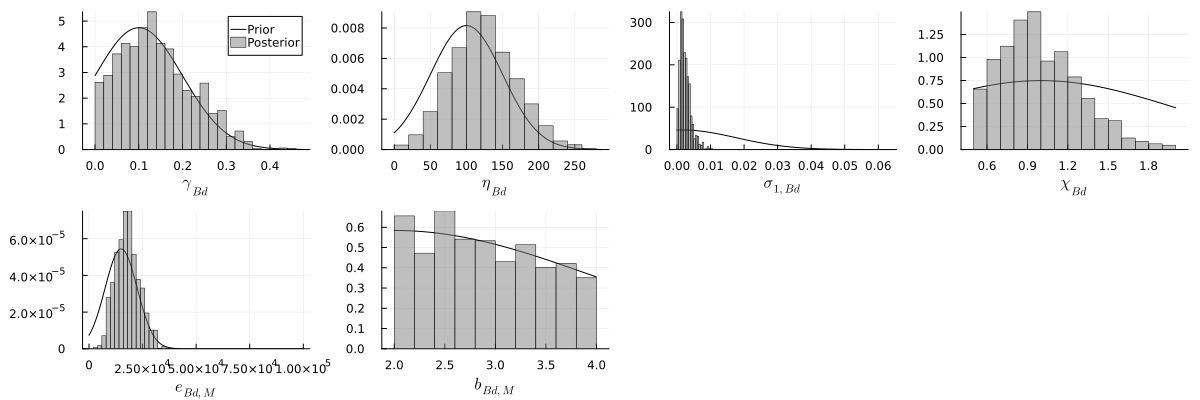

"c:\\Users\\simon\\Documents\\AmphiDEBResearch\\WP02_TKTD\\data\\sims\\Discoglossus_BdJEL423_exp2\\marginal_posteriors.png"

In [ ]:
import Plots:plot
plot(dist::Hyperdist) = plot(dist.dist)
@info "#### ---- Marginal posteriors ---- ####"

        let plt, num_params = length(f.prior.dists), num_cols = 4, num_rows = Int(ceil(num_params / num_cols))

            plt = plot(
                plot.(f.prior.dists, color = :black)..., 
                layout = (num_rows, num_cols), 
                leg = hcat(vcat(true, repeat([false], num_params-1))...), 
                label = "Prior", 
                size = (1200,200*num_rows), bottommargin = 5mm
                )
        
                
            for (i,param) in enumerate(f.prior.labels)
        
                histogram!(
                    plt, subplot = i, 
                    f.accepted[i,:], weights = Weights(vec(f.weights)), 
                    xlabel = param in keys(paramlabels) ? paramlabels[param] : param, 
                    normalize = :pdf, label = "Posterior", color = :gray, lw = 0.5, fillalpha = .5
                    )
            end
        
            display(plt)
            
            if !isnothing(savetag)
                savefig(plot(plt, dpi = 400), datadir("sims", "$(savetag)", "marginal_posteriors.png"))
            end
        end

### Parameter estimates and uncertainty

In [19]:
generate_posterior_summary(
    f; 
    tex = true,
    paramlabels = paramlabels,
    savedir = savedir,
    savetag = savetag
) |> display

Row,param,best_fit,median,q05,q95
,String,Float64,Float64,Float64,Float64
1,pth.gamma,0.274825,0.130112,0.0194089,0.288229
2,pth.eta,65.9992,120.807,52.5461,199.672
3,pth.sigma1,0.00188388,0.00212595,0.000526521,0.00574223
4,spc.Chi,0.927234,0.961003,0.580217,1.54817
5,spc.E_P[2],19280.3,17676.6,9232.07,27616.3
6,spc.B_P[2],2.23534,2.84945,2.07438,3.8427
